In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from scipy.stats import norm, bernoulli
import json
import warnings; warnings.simplefilter('ignore')
from tqdm import tqdm
import re
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
# load in appropriate packages
import seaborn as sns
import matplotlib.pyplot as plt
import os, sys
from scipy.stats import norm, bernoulli, beta, expon
import matplotlib.patheffects as pe
import cvxpy as cp
from IPython.display import clear_output
import time
from patsy import dmatrix # For generating spline basis
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches


In [3]:
master_df = pd.read_csv("chex_chexmodel_withpreds_new.csv")

In [4]:
# If want to analyze Edema
# ensure numeric (coerce strings to NaN)
master_df["Edema"] = pd.to_numeric(master_df["Edema"], errors="coerce")

# keep only rows where Effusion is exactly 0 or 1
master_df = master_df[master_df["Edema"].isin([0.0, 1.0])].copy()
master_df["Edema"] = master_df["Edema"].astype("Int64")

In [27]:
np.sum(master_df['Sex_0/1'] == 1) # number of men

4777

In [29]:
contingency = pd.crosstab(master_df['Sex_0/1'], master_df['Edema'])
contingency.columns = ['No PE', 'PE']
n0, n1 = contingency.sum(axis=1) #number of M (gp 1) and number of W (gp0)
mu1 = contingency.iloc[1,1] / n1
mu0 = contingency.iloc[0,1] / n0
OR = mu1/(1 - mu1)/(mu0/(1-mu0))
contingency

,No PE,PE
Sex_0/1,,
0,2623,503
1,4084,693


In [30]:
OR

0.8848666083810555

In [7]:
# confusion matrix for predictions
# --- find the right column names (prob + ground truth) ---
df = master_df.copy()
prob_col_candidates = ["prob_Edema", "prob_Effusion"]
gt_col_candidates   = ["Edema", "Effusion"]  # CheXpert uses "Edema"

prob_col = next((c for c in prob_col_candidates if c in df.columns), None)
gt_col   = next((c for c in gt_col_candidates   if c in df.columns), None)
if prob_col is None or gt_col is None:
    raise KeyError(f"Could not find columns. Have: {df.columns.tolist()[:20]} ...")

# --- restrict to rows with valid GT (0/1) and non-missing predictions ---
work = df.loc[df[gt_col].isin([0, 1])].copy()
work = work.dropna(subset=[prob_col])  # drop rows that didn’t get a prediction

# --- threshold at 0.5 to get predicted labels ---
work["y_true"] = work[gt_col].astype(int)
work["y_pred"] = (work[prob_col] >= 0.5).astype(int)

# --- confusion matrix counts ---
# TN = (true 0, pred 0), FP = (true 0, pred 1), FN = (true 1, pred 0), TP = (true 1, pred 1)
cm = pd.crosstab(work["y_true"], work["y_pred"], dropna=False)
cm = cm.reindex(index=[0,1], columns=[0,1], fill_value=0)  # ensure full 2x2
cm.index  = ["True 0", "True 1"]
cm.columns = ["Pred 0", "Pred 1"]
print(cm)

        Pred 0  Pred 1
True 0    5263    1444
True 1     144    1052


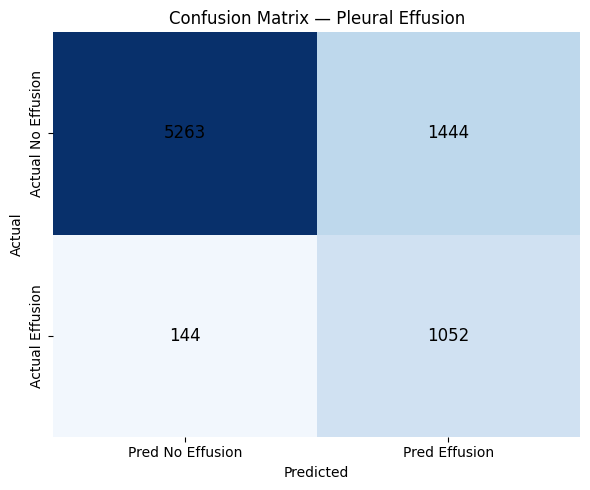

=== Overall (Pleural Effusion) ===
N=7903 | Acc=0.799 | AUC=0.902 | Prec=0.421 | Rec/Sens=0.880 | F1=0.570
Confusion matrix (rows=true, cols=pred):
[[TN=5263, FP=1444],
 [FN=144, TP=1052]]


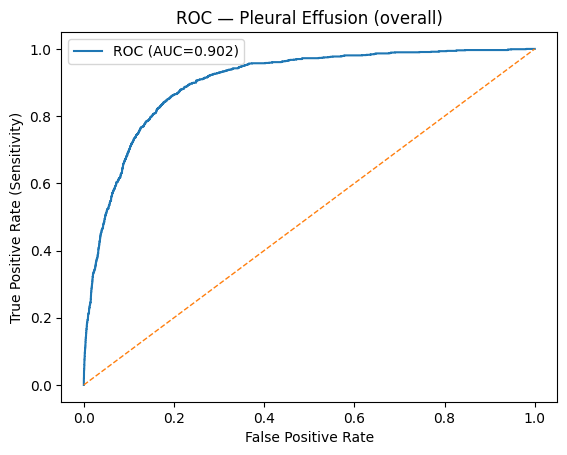

[Female (0)] N=3126 | Acc=0.804 | AUC=0.904 | Prec=0.446 | Rec=0.887 | F1=0.593


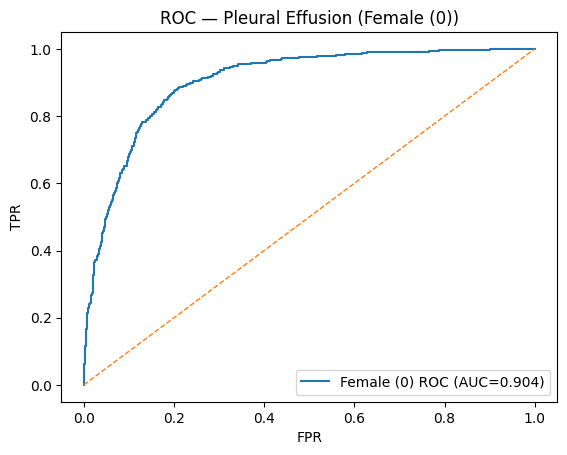

[Male (1)] N=4777 | Acc=0.796 | AUC=0.901 | Prec=0.405 | Rec=0.874 | F1=0.554


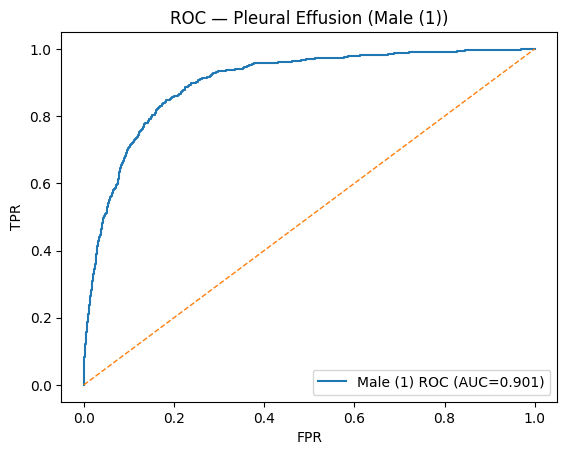

In [8]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, precision_recall_fscore_support

# --- pick your DataFrame ---
df = master_df   # or merged

# --- find columns robustly ---
#prob_col_candidates = ["prob_Pleural Effusion", "prob_Effusion"]
#gt_col_candidates   = ["Pleural Effusion", "Effusion"]
prob_col_candidates = ["prob_Edema", "prob_Effusion"]
gt_col_candidates   = ["Edema", "Effusion"]
sex_col_candidates  = ["Sex_0/1", "Sex"]  # will map "Female"/"Male" to 0/1 if needed

prob_col = next((c for c in prob_col_candidates if c in df.columns), None)
gt_col   = next((c for c in gt_col_candidates   if c in df.columns), None)
sex_col  = next((c for c in sex_col_candidates  if c in df.columns), None)
assert prob_col and gt_col and sex_col, f"Missing needed columns. Have: {df.columns.tolist()}"

# --- make a working copy with clean ground truth & sex binary ---
work = df.copy()

# keep only true 0/1 labels for GT
work[gt_col] = pd.to_numeric(work[gt_col], errors="coerce")
work = work[work[gt_col].isin([0, 1])].copy()

# drop rows without predictions
work = work.dropna(subset=[prob_col]).copy()

# ensure sex binary 0/1
if work[sex_col].dtype == object:
    work[sex_col] = work[sex_col].map({"Female":0, "Male":1})
work = work.dropna(subset=[sex_col]).copy()
work[sex_col] = work[sex_col].astype(int)

y_true = work[gt_col].astype(int).to_numpy()
y_prob = work[prob_col].to_numpy()
y_pred = (y_prob >= 0.5).astype(int)

import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5), facecolor="white")
ax = sns.heatmap(
    cm, annot=False, cmap="Blues", cbar=False,
    xticklabels=['Pred No Effusion','Pred Effusion'],
    yticklabels=['Actual No Effusion','Actual Effusion'],
    vmin=0, vmax=cm.max()
)

# Manually add annotations (always visible)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, f"{cm[i, j]:d}",
                ha="center", va="center", color="black", fontsize=12)

plt.title('Confusion Matrix — Pleural Effusion')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()
# ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
#                  xticklabels=['Pred No Effusion','Pred Effusion'],
#                  yticklabels=['Actual No Effusion','Actual Effusion'])
# thr = cm.max()/2
# for t in ax.texts:
#     val = int(t.get_text())
#     t.set_color('white' if val > thr else 'black')
# plt.title('Confusion Matrix')
# plt.ylabel('Actual'); plt.xlabel('Predicted')
# plt.tight_layout(); plt.show()

# --- overall metrics ---
auc  = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan
acc  = (y_pred == y_true).mean()
tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)

print("=== Overall (Pleural Effusion) ===")
print(f"N={len(y_true)} | Acc={acc:.3f} | AUC={auc:.3f} | Prec={prec:.3f} | Rec/Sens={rec:.3f} | F1={f1:.3f}")
print(f"Confusion matrix (rows=true, cols=pred):\n[[TN={tn}, FP={fp}],\n [FN={fn}, TP={tp}]]")

# --- ROC curve overall ---
fpr, tpr, thr = roc_curve(y_true, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC — Pleural Effusion (overall)")
plt.legend()
plt.show()

# --- metrics by sex ---
def metrics_subset(mask, label):
    yt, yp, yhat = y_true[mask], y_prob[mask], y_pred[mask]
    if len(yt) == 0 or len(np.unique(yt)) < 2:
        print(f"[{label}] Not enough positive/negative cases for AUC.")
        return
    auc  = roc_auc_score(yt, yp)
    acc  = (yhat == yt).mean()
    tn, fp, fn, tp = confusion_matrix(yt, yhat, labels=[0,1]).ravel()
    prec, rec, f1, _ = precision_recall_fscore_support(yt, yhat, average="binary", zero_division=0)
    print(f"[{label}] N={len(yt)} | Acc={acc:.3f} | AUC={auc:.3f} | Prec={prec:.3f} | Rec={rec:.3f} | F1={f1:.3f}")
    fpr, tpr, _ = roc_curve(yt, yp)
    plt.figure()
    plt.plot(fpr, tpr, label=f'{label} ROC (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'--', linewidth=1)
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC — Pleural Effusion ({label})"); plt.legend(); plt.show()

mask_f = (work[sex_col].to_numpy() == 0)
mask_m = (work[sex_col].to_numpy() == 1)

metrics_subset(mask_f, "Female (0)")
metrics_subset(mask_m, "Male (1)")


In [9]:
Yhat = np.array(master_df["prob_Edema"])
Y = np.array(master_df['Edema']) * 1
men = np.array(master_df['Sex_0/1'] == 1)
Yhat1, Yhat0 = Yhat[men], Yhat[~men]
Y1, Y0 = Y[men], Y[~men]
n0, n1 = len(Y0), len(Y1)
n = n0 + n1

In [25]:
n1, n0

(4777, 3126)

In [10]:
mu0 = Y0.mean()
mu1 = Y1.mean()
true_odds_ratio = (mu1 / (1 - mu1)) / (mu0 / (1 - mu0))
true_var = (1/np.sum(Y0==0) + 1/np.sum(Y0==1) + 1/np.sum(Y1==0) + 1/np.sum(Y1==1))*n

In [31]:
true_odds_ratio

0.8848666083810555

## Optimization code

In [11]:
# setup_spline_basis
def setup_spline_basis(uncertainties, num_knots=5, degree=3, name='u'):
    """
    Sets up B-spline basis functions for given uncertainties. 
    """
    if len(uncertainties) == 0:
        return np.zeros((0, 0)), None # Handle empty input
        
    # Ensure enough unique points relative to knots/degree
    unique_uncertainties = np.unique(uncertainties)
    required_unique = degree + 1 
    if len(unique_uncertainties) < required_unique:
         print(f"Warning: Need at least {required_unique} unique uncertainty points for degree {degree} spline, "
               f"found {len(unique_uncertainties)}. Reducing degree or complexity might be needed.")

    if len(unique_uncertainties) < num_knots + 1:
        num_knots = max(0, len(unique_uncertainties) - degree - 1) # Try to leave enough points between knots


    # Define knot locations (e.g., quantiles)
    knot_quantiles = np.linspace(0, 1, num_knots + 2)[1:-1] 
    
    # Handle case where all uncertainties are the same
    if len(unique_uncertainties) == 1:
         knots = np.array([]) # No internal knots
         num_knots = 0 # Force num_knots to 0
         # Use df instead of knots for constant case
         formula = f"bs({name}, df={degree+1}, degree={degree}, include_intercept=True) - 1"
         data = {name: uncertainties}
         try:
              basis_matrix = dmatrix(formula, data, return_type='dataframe')
              return basis_matrix.values, None
         except Exception as e:
             print(f"Patsy error even with df for constant uncertainty: {e}. Returning basic constant basis.")
             # Fallback to a truly constant basis (vector of ones)
             return np.ones((len(uncertainties), 1)), None


    # Proceed with knot calculation for non-constant cases
    if num_knots > 0:
         knots = np.quantile(uncertainties, knot_quantiles)
         knots = np.unique(knots) # Ensure knots are unique
         # Check if knots collapsed or are too close to boundaries
         min_u, max_u = np.min(uncertainties), np.max(uncertainties)
         # Remove knots too close to the boundary? Sometimes helps patsy.
         # knots = knots[(knots > min_u) & (knots < max_u)] 
         if len(knots) < num_knots:
              # print(f"Warning: Number of unique knots reduced to {len(knots)}.")
              pass # Let patsy handle fewer knots
         if len(knots) == 0 and num_knots > 0:
              print("Warning: All internal knots collapsed. Proceeding without internal knots.")
              num_knots = 0 # Update num_knots if they vanished

    else: # num_knots is 0
         knots = np.array([])

    # Create the design matrix using patsy
    # Use bs() for B-splines
    if num_knots > 0:
        formula = f"bs({name}, knots=knots, degree=degree, include_intercept=True) - 1"
    else: # No internal knots, use df
         df = degree + 1 # Number of basis functions for degree d, no internal knots
         formula = f"bs({name}, df={df}, degree={degree}, include_intercept=True) - 1"

    data = {name: uncertainties}
    
    try:
        basis_matrix = dmatrix(formula, data, return_type='dataframe')
    except Exception as e:
         print(f"Patsy error: {e}. Trying simpler df if knots were used.")
         try:
             # Fallback if specific knot creation failed
             df = num_knots + degree + 1 # Total degrees of freedom expected
             formula = f"bs({name}, df={df}, degree={degree}, include_intercept=True) - 1"
             basis_matrix = dmatrix(formula, data, return_type='dataframe')
             knots = None # Knots aren't explicitly defined in this case
         except Exception as e2:
             print(f"Patsy fallback failed: {e2}. Returning basic constant basis.")
             return np.ones((len(uncertainties), 1)), None


    # Check if basis matrix has expected shape
    expected_cols = num_knots + degree + 1 # Intercept is included in the count here
    if basis_matrix.shape[1] == 0 and expected_cols > 0 :
         print(f"Warning: Patsy generated an empty basis matrix ({basis_matrix.shape}). Check inputs/parameters. Returning constant basis.")
         return np.ones((len(uncertainties), 1)), None
         
    return basis_matrix.values, knots # Return as numpy array



In [12]:
def sampling_probs_spline_inv(u1_all, u0_all, b1, b0, mu1, mu0, n_budget, num_knots=5, degree=3, verbose_solver=False):
    """
    Compute optimal sampling probabilities parametrized by splines on INVERSE probabilities.
    MODIFIED TO PRIORITIZE MOSEK SOLVER.

    Models log(1/p_i) = B(u_i) @ theta, such that 1/p_i >= 1.

    Args:
        u1_all (np.ndarray): Individual uncertainty scores for group 1 points.
        u0_all (np.ndarray): Individual uncertainty scores for group 0 points.
        b1 (np.ndarray): individual scores (potentially diff from uncertainty scores) for constructing spline basis for group 1 points.
        b0 (np.ndarray): individual scores ("") for constructing spline basis for group 0 points.
        mu1 (float): Estimated mean for group 1 (used for scaling objective).
        mu0 (float): Estimated mean for group 0 (used for scaling objective).
        n_budget (float): Total expected sample budget.
        num_knots (int): Number of internal knots for the splines.
        degree (int): Degree of the spline polynomials.
        verbose_solver (bool): If True, show detailed solver output.

    Returns:
        tuple: (probs1, probs0, spline_params1, spline_params0)
               probs1 (np.ndarray): Sampling probabilities for group 1 points.
               probs0 (np.ndarray): Sampling probabilities for group 0 points.
               spline_params1 (dict): Info about group 1 spline (coeffs, knots, degree).
               spline_params0 (dict): Info about group 0 spline (coeffs, knots, degree).
        Returns (None, None, None, None) if optimization fails.
    """
    overall_start_time = time.perf_counter()
    n1 = len(u1_all)
    n0 = len(u0_all)

    if n1 == 0 and n0 == 0:
        print("Warning: Both groups are empty.")
        return np.array([]), np.array([]), None, None
    if n_budget <= 0:
         print("Warning: Budget is non-positive. Returning zero probabilities.")
         return np.zeros(n1), np.zeros(n0), None, None

    # --- Setup Spline Basis (Same as before) ---
    B1, knots1 = np.zeros((n1, 0)), None
    B0, knots0 = np.zeros((n0, 0)), None
    n_basis1 = 0
    n_basis0 = 0

    if n1 > 0:
        try:
             #B1, knots1 = setup_spline_basis(u1_all, num_knots, degree, name='u1')
             B1, knots1 = setup_spline_basis(b1, num_knots, degree, name = 'u1')
             n_basis1 = B1.shape[1]
             if n_basis1 == 0: raise ValueError("Basis matrix is empty")
        except Exception as e:
            print(f"Could not create spline basis for group 1: {e}. Check uncertainty values.")
            n_basis1 = 0 # Ensure it's zero
    if n0 > 0:
        try:
            B0, knots0 = setup_spline_basis(b0, num_knots, degree, name = 'u0')
            #B0, knots0 = setup_spline_basis(u0_all, num_knots, degree, name='u0')
            n_basis0 = B0.shape[1]
            if n_basis0 == 0: raise ValueError("Basis matrix is empty")
        except Exception as e:
             print(f"Could not create spline basis for group 0: {e}. Check uncertainty values.")
             n_basis0 = 0 # Ensure it's zero

    if n_basis1 == 0 and n_basis0 == 0 and (n1 > 0 or n0 > 0):
         print("Error: Could not create spline basis for either group. Cannot optimize.")
         return None, None, None, None

    # --- CVXPY Optimization
    theta1 = cp.Variable(n_basis1, name="theta1") if n_basis1 > 0 else None
    theta0 = cp.Variable(n_basis0, name="theta0") if n_basis0 > 0 else None

    log_x1, log_x0 = None, None
    x1, x0 = None, None
    p1, p0 = None, None

    constraints = []
    objective_terms = []
    budget_terms = []

    # Group 1 calculations
    if n1 > 0 and n_basis1 > 0 and theta1 is not None and mu1 > 0 and mu1 < 1:
        w1 = u1_all / (n1**2 * (mu1**2) * (1 - mu1)**2)
        log_x1 = B1 @ theta1
        x1 = cp.exp(log_x1)
        p1 = cp.exp(-log_x1)
        objective_terms.append(cp.sum(cp.multiply(w1, x1)))
        budget_terms.append(cp.sum(p1))
        #budget_terms.append(-log_x1)
        constraints.append(log_x1 >= 0)
    elif n1 > 0:
         print(f"Warning: Skipping group 1 contributions (n1={n1}, n_basis1={n_basis1}, mu1={mu1})")

    # Group 0 calculations
    if n0 > 0 and n_basis0 > 0 and theta0 is not None and mu0 > 0 and mu0 < 1:
        w0 = u0_all / (n0**2 * (mu0**2) * (1 - mu0)**2)
        log_x0 = B0 @ theta0
        x0 = cp.exp(log_x0)
        p0 = cp.exp(-log_x0)
        objective_terms.append(cp.sum(cp.multiply(w0, x0)))
        budget_terms.append(cp.sum(p0))
        #budget_terms.append(-log_x0)
        constraints.append(log_x0 >= 0)
    elif n0 > 0:
        print(f"Warning: Skipping group 0 contributions (n0={n0}, n_basis0={n_basis0}, mu0={mu0})")

    if not objective_terms:
         print("Error: No valid objective terms could be constructed.")
         return None, None, None, None

    # Objective function: Minimize sum of weighted inverse probabilities (w_i * x_i)
    objective = cp.Minimize(cp.sum(objective_terms))

    # Budget Constraint: sum(p_i) <= n_budget
    if budget_terms: # Only add budget constraint if there are probabilities to sum
        constraints.append(cp.sum(budget_terms) <= n_budget)
        #log_xs = cp.multiply(np.ones(len(budget_terms), budget_terms))
        #constraints.append(cp.log_sum_exp(-cp.hstack(budget_terms)) <= cp.log(n_budget))
    else:
         print("Warning: No variables to constrain budget.")

    problem = cp.Problem(objective, constraints)

    # --- Solve the problem with MOSEK, falling back to ECOS, then SCS ---
    # Define solver priority list
    solver_list = [cp.MOSEK, cp.ECOS, cp.SCS]
    solved = False

    for solver_name in solver_list: # solver_name is 'MOSEK', 'ECOS', or 'SCS'

        #print(f"Attempting to solve with {solver_name}...")
        try:
            # --- Solver Specific Arguments & Options ---
            # Start with common arguments
            solver_kwargs = {
                'verbose': verbose_solver,
                # General tolerance arguments might be added here,
                # but specific ones are often better handled below.
            }

            # --- Configure solver-specific arguments ---

            if solver_name == cp.ECOS: # Or just 'ECOS'
                 # ECOS takes arguments directly
                 solver_kwargs['max_iters'] = 200
                 solver_kwargs['abstol'] = 1e-8 # Example specific tolerances
                 solver_kwargs['reltol'] = 1e-7

            elif solver_name == cp.SCS: # Or just 'SCS'
                 # SCS takes arguments directly
                 solver_kwargs['eps'] = 1e-5 # Example specific tolerance

            # --- Solve ---
            # Unpack the prepared kwargs dictionary. If solver is MOSEK,
            # this will now directly pass MSK_DPAR... arguments.
            #print(f"Passing kwargs to {solver_name}: {solver_kwargs}") # Debug print
            problem.solve(solver=solver_name, **solver_kwargs)
            final_status = problem.status

            # --- Check Status ---
            # If solved optimally or inaccurately, stop trying other solvers
            if problem.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
                #print(f"{solver_name} finished with status: {problem.status}")
                solved = True
                break # Exit the loop
            else:
                print(f"{solver_name} failed with status: {problem.status}")
                # Continue to the next solver in the list

        except (cp.SolverError, ValueError, ImportError) as e:
             # ImportError can happen if solver seems installed but has runtime issues (e.g., MOSEK license)
            print(f"{solver_name} solver encountered an error: {e}")
            # Continue to the next solver in the list

    if not solved:
        print("All attempted solvers failed to find an optimal or inaccurate solution.")
        # Ensure problem status reflects the failure if loop finishes without success
        if problem.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
             problem.status = "solver_error"


    # --- Check for solution (rest of the code is the same) ---
    overall_end_time = time.perf_counter()
    if problem.status in ["optimal", "optimal_inaccurate"]:
        #print(f"Optimization successful (Final Status: {problem.status}). Objective value: {problem.value}")
        #print(f"Total Time: {overall_end_time - overall_start_time:.4f} seconds") # Added total time

        final_probs1 = np.zeros(n1)
        final_probs0 = np.zeros(n0)
        final_theta1 = None
        final_theta0 = None

        # Retrieve results safely (check if variables and .value exist)
        if p1 is not None and theta1 is not None and hasattr(theta1, 'value') and theta1.value is not None:
            final_theta1 = theta1.value
            try:
                 log_x1_opt = B1 @ final_theta1
                 final_probs1 = np.exp(-log_x1_opt)
                 final_probs1 = np.clip(final_probs1, 0, 1)
            except Exception as calc_e:
                 print(f"Error calculating final probabilities for group 1: {calc_e}")
                 final_probs1 = np.zeros(n1) # Fallback
                 final_theta1 = None # Invalidate theta if calc failed

        if p0 is not None and theta0 is not None and hasattr(theta0, 'value') and theta0.value is not None:
            final_theta0 = theta0.value
            try:
                log_x0_opt = B0 @ final_theta0
                final_probs0 = np.exp(-log_x0_opt)
                final_probs0 = np.clip(final_probs0, 0, 1)
            except Exception as calc_e:
                 print(f"Error calculating final probabilities for group 0: {calc_e}")
                 final_probs0 = np.zeros(n0) # Fallback
                 final_theta0 = None # Invalidate theta if calc failed

        # Store spline parameters
        spline_params1 = {'coeffs': final_theta1, 'knots': knots1, 'degree': degree, 'n_basis': n_basis1} if n_basis1 > 0 and final_theta1 is not None else None
        spline_params0 = {'coeffs': final_theta0, 'knots': knots0, 'degree': degree, 'n_basis': n_basis0} if n_basis0 > 0 and final_theta0 is not None else None

        # Sanity check budget constraint
        actual_expected_samples = np.sum(final_probs1) + np.sum(final_probs0)
        # Use a slightly larger tolerance for feasibility checks after solve
        # Check against 1% deviation or a small absolute value
        upper_bound = max(n_budget * 1.01, n_budget + 1e-4)
        lower_bound = min(n_budget * 0.99, n_budget - 1e-4)

        if actual_expected_samples > upper_bound:
             print(f"Warning: Calculated expected samples ({actual_expected_samples:.4f}) "
                   f"significantly exceed budget ({n_budget:.4f}). Status: {problem.status}")
        # Check for underutilization only if budget likely should have been tight (objective > 0)
        elif actual_expected_samples < lower_bound and abs(problem.value) > 1e-6:
              print(f"Warning: Calculated expected samples ({actual_expected_samples:.4f}) "
                   f"is significantly under budget ({n_budget:.4f}). Solution might be suboptimal if budget wasn't tight.")


        return final_probs1, final_probs0, spline_params1, spline_params0

    else:
        print(f"Problem not solved optimally. Final Status: {problem.status}")
        print(f"Total Time: {overall_end_time - overall_start_time:.4f} seconds")
        return None, None, None, None

## Helper functions

In [13]:
def opt_mean_tuning(Y, Yhat, weights, sampling_ratio): #lambda star is sum of Y * f where f is Yhat * weights * sampling ratio
    return np.clip(np.mean(Y*Yhat*weights*sampling_ratio)/np.mean(Yhat**2*sampling_ratio), 0, 1)

def odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights0, weights1, alpha, lhat0=None, lhat1=None):
    n0 = Y0.shape[0]
    n1 = Y1.shape[0]    
    mu0_hat = np.mean(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*weights0)
    mu1_hat = np.mean(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*weights1)
    pointest_log = np.log(mu1_hat/(1-mu1_hat)) - np.log(mu0_hat/(1-mu0_hat))
    var_mu0_hat = np.var(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*weights0)
    var_mu1_hat = np.var(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*weights1)
    var0 = var_mu0_hat/((mu0_hat*(1-mu0_hat))**2)
    var1 = var_mu1_hat/((mu1_hat*(1-mu1_hat))**2)
    p0 = n0/(n0+n1)
    p1 = n1/(n0+n1)
    var = 1/p0*var0 + 1/p1*var1
    width_log = norm.ppf(1-alpha/2)*np.sqrt(var/(n0+n1))
    return np.exp(pointest_log - width_log), np.exp(pointest_log + width_log), var

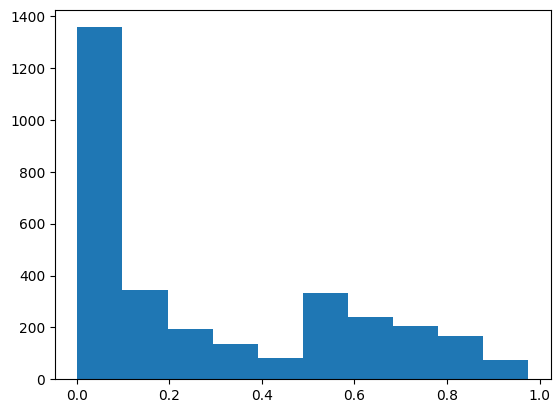

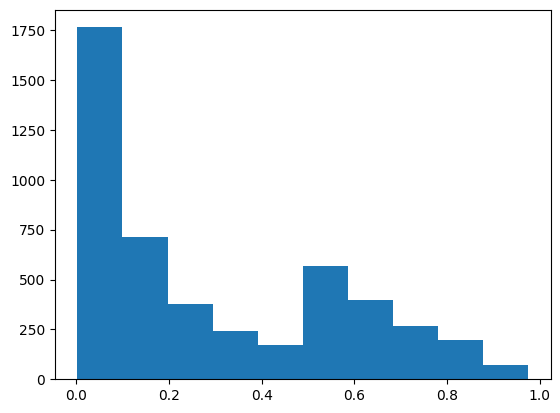

In [14]:
plt.hist(Yhat0) #african american
plt.show()
plt.hist(Yhat1) #white
plt.show()


## Plotting code

In [16]:
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

In [17]:
def plot_eff_sample_size(df, plot_title):
    df = df[df.estimator != "LLM only"]
    ylab = "$n_{\mathrm{effective}}$"
    xlab = "$n_{\mathrm{human}}$"

    desired_order = ["active", "active + tuning", 
                     "spline", "spline + tuning", 
                     "uniform", "classical"]

    color_map = {"active": 'tab:orange', 
                 "active + tuning": 'tab:orange',
                 "spline": 'tab:green',
                 "spline + tuning": 'tab:green',
                 "uniform": 'tab:blue',
                 "classical": 'tab:purple'}
    
    linestyle_map = {
        "active": "-",
        "active + tuning": "--",   # dashed
        "spline": "-",
        "spline + tuning": "--",
        "uniform": "-",
        "classical": "-"
    }

    markers = ["o", "o", "s", "s", "D", "X"]  # Different marker shapes
    sns.set_theme(font_scale=2.2, style='white', rc={'lines.linewidth': 3})
    df_mean = df.groupby([xlab, 'estimator'])[ylab].mean().reset_index()
    fig, ax = plt.subplots(figsize=(7, 8))

    for i, est in enumerate(desired_order):
        subset = df_mean[df_mean['estimator'] == est]
        ax.plot(subset[xlab], subset[ylab],
                label=est,
                color=color_map[est],
                linestyle=linestyle_map[est],
                #linestyle='-' if dashes_map[est] == "" else None,
                #dashes=None if dashes_map[est] == "" else dashes_map[est],
                marker=markers[i],
                markersize=10,
                linewidth=2)
        # ax.fill_between(subset[xlab], subset_lower[ylab], subset_upper[ylab],
        #                 color=color_map[est],
        #                 alpha=0.2)

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    sns.despine(top=True, right=True)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend().remove()

    #ax.set_yticks(np.arange(100, 500+1, 100))

    # making a fake legend
    
    
    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight')
    plt.show()
    # sns.lineplot(data=df_mean, x=xlab, y=ylab, hue='estimator', hue_order=desired_order, ax=ax,
    #              style='estimator', markers=markers, linewidth=2, alpha=0.7, legend=False)
    # sns.scatterplot(data=df_mean, x=xlab, y=ylab, hue='estimator', hue_order=desired_order, ax=ax, s=70, alpha=0.7, edgecolor='black', style='estimator', markers=markers)
    # ax.legend().remove()
    # ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    # sns.despine(top=True, right=True)
    # plt.tight_layout()
    # plt.savefig(plot_title, bbox_inches='tight')
    # plt.show()

In [18]:
def plot_coverage(df, alpha, plot_title):
    # ────────────────────────────────────
    # 1.  keep six estimators of interest
    # ────────────────────────────────────
    desired_order = ["active", "active + tuning",
                     "spline", "spline + tuning",
                     "uniform", "classical"]
    df = df[df.estimator.isin(desired_order)].copy()

    # optional: make "LLM only" flat (kept for completeness; remove if unused)
    if "LLM only" in df.estimator.unique():
        llm_only_mean = df.loc[df.estimator == "LLM only", "coverage"].mean()
        df.loc[df.estimator == "LLM only", "coverage"] = llm_only_mean

    # ────────────────────────────────────
    # 2.  aesthetic maps
    # ────────────────────────────────────
    color_map = {"active":           'tab:orange',
                 "active + tuning":  'tab:orange',
                 "spline":           'tab:green',
                 "spline + tuning":  'tab:green',
                 "uniform":          'tab:blue',
                 "classical":        'tab:purple'}

    linestyle_map = {"active": "--",           # all dashed in screenshot style
                     "active + tuning": ":",
                     "spline": "--",
                     "spline + tuning": ":",
                     "uniform": "--",
                     "classical": "--"}

    marker_map = {"active": "o", "active + tuning": "o",
                  "spline": "s", "spline + tuning": "s",
                  "uniform": "D", "classical": "X"}

    # ────────────────────────────────────
    # 3.  prepare data (mean over trials)
    # ────────────────────────────────────
    xlab = r"$n_{\mathrm{human}}$"
    ylab = "coverage"

    df_mean = (df.groupby([xlab, "estimator"], observed=True)[ylab]
                 .mean()
                 .reset_index())

    # ────────────────────────────────────
    # 4.  plot
    # ────────────────────────────────────
    sns.set_theme(font_scale=2.2,
                  style="white",
                  rc={"lines.linewidth": 3, "axes.linewidth": 2})

    fig, ax = plt.subplots(figsize=(7, 5))

    for est in desired_order:
        sub = df_mean[df_mean["estimator"] == est]
        if sub.empty:
            continue

        # dashed trend line
        ax.plot(sub[xlab], sub[ylab],
                label=est,
                color=color_map[est],
                linestyle=linestyle_map[est],
                linewidth=2)

        # filled marker with thin black edge (no white halo)
        ax.scatter(sub[xlab], sub[ylab],
                   marker=marker_map[est],
                   s=120,                    # marker size
                   color=color_map[est],
                   edgecolor='none',
                   zorder=3)

    # nominal line at 1-alpha
    ax.axhline(1 - alpha, color="#888888",
               linestyle="--", linewidth=1, alpha=0.7, zorder=1)

    # axes, grid, ticks
    ax.grid(True, which='both', linestyle='--',
            linewidth=0.5, color='gray', alpha=0.7)
    sns.despine(ax=ax, top=True, right=True)

    ax.set_xlabel(xlab, fontstyle='italic')
    ax.set_ylabel(ylab, fontstyle='italic')
    ax.set_ylim(0.75, 1.05)
    ax.set_yticks(np.linspace(0.75, 1, 6))
    ax.tick_params(axis='both', direction='in', width=2, length=6)

    # no legend box (comment out to show)
    if ax.get_legend():
        ax.legend().remove()

    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight', dpi=300)
    plt.show()

In [19]:
def plot_intervals(
        df,
        true_val,
        num_trials,
        estimand_title,
        plot_title,
        n_ind=-1,          # which n_human slice (−1 == last / largest)
        num_ints=5,        # intervals per estimator to show
        bar_height=0.8,    # in y–grid units (≤1.0)
        gap=0.3            # vertical gap between colour groups
):
    # ─── 1. estimator order & style maps ─────────────────────────────────
    methods = ["active", "active + tuning",
               "spline", "spline + tuning",
               "uniform", "classical"]

    colours = {"active":           "#F29F5B",   # orange
               "active + tuning":  "#F29F5B",
               "spline":           "#6EAD61",   # green
               "spline + tuning":  "#6EAD61",
               "uniform":          "#5D8DB9",   # blue
               "classical":        "#9B59B6"}   # purple

    hatches = {"active": "",
               "active + tuning": "///",
               "spline": "",
               "spline + tuning": "///",
               "uniform": "",
               "classical": ""}

    # ─── 2. choose n_human slice & sample rows ───────────────────────────
    ns = np.sort(df["$n_{\\mathrm{human}}$"].unique())
    n_human = ns[n_ind]

    # randomly choose the row positions once, reuse across estimators
    rng_rows  = np.random.choice(num_trials, num_ints, replace=False)

    # build a list of (estimator, lo, hi) in desired plotting order
    rows_to_plot = []
    for est in methods:
        subset = df[(df.estimator == est) & (df["$n_{\\mathrm{human}}$"] == n_human)]
        if len(subset) == 0:
            continue                     # skip if estimator absent
        subset = subset.iloc[rng_rows % len(subset)]  # safe wrap
        for _, r in subset.iterrows():
            rows_to_plot.append((est, r.lb, r.ub))

    # reverse so first interval appears at top
    rows_to_plot = rows_to_plot[::-1]

    # ─── 3. figure size: 0.45″ per interval row works well ───────────────
    fig_h = max(4, 0.45 * len(rows_to_plot))
    sns.set_theme(font_scale=2.2, style='white', rc={'axes.linewidth': 2})
    fig, ax = plt.subplots(figsize=(7, fig_h))

    # vertical reference
    ax.axvline(true_val, color='gray', linestyle='--', linewidth=1)
    xmax = 0
    xmin = 2
    # ─── 4. add rectangles, one y–unit per interval ──────────────────────
    for y, (est, lo, hi) in enumerate(rows_to_plot):
        rect = mpatches.Rectangle(
            (lo, y - bar_height/2),          # (x-left, y-bottom)
            hi - lo,                         # width
            bar_height,                      # height
            facecolor=lighten_color(colours[est], 0.35),
            edgecolor='black',
            linewidth=1,
            hatch=hatches[est],
            zorder=3
        )
        ax.add_patch(rect)
        xmax = max(xmax, hi)
        xmin = min(xmin, lo)

    # ─── 5. tidy up axes ─────────────────────────────────────────────────
    ymax = len(rows_to_plot) - 0.5
    ymin = -0.5
    ax.set_ylim(ymax + gap, ymin)           # invert y so first row at top
    ax.set_yticks([])

    # x-limits: add 5 % padding either side
    #xmin = df[["lb", "ub"]].min().min()
    #xmax = df[["lb", "ub"]].max().max()
    pad  = 0.05 * (xmax - xmin)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_xlabel(estimand_title, fontstyle='italic')
    sns.despine(ax=ax, top=True, right=True, left=True)
    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight', dpi=300)
    plt.show()


## Experiment

In [20]:
mu1_train, mu0_train = np.mean(Yhat1), np.mean(Yhat0)

In [21]:
np.random.seed(614)
alpha = 0.1 # desired error level for confidence interval
fracs_human = np.linspace(0.1, 0.2, 20) # sampling budget
#fracs_human = [0.2]
num_trials = 100

num_methods = 6

temp_df = pd.DataFrame({
    "lb": np.zeros(num_methods),
    "ub": np.zeros(num_methods),
    "interval width": np.zeros(num_methods),
    "coverage": np.zeros(num_methods),
    "estimator": [""] * num_methods,
    "$n_{\mathrm{human}}$": np.zeros(num_methods),
    "$n_{\mathrm{effective}}$": np.zeros(num_methods)
})

#tau = 1 # mix with uniform if want
tau = 0.5

results = []

for j in tqdm(range(len(fracs_human))):
    frac_human = fracs_human[j]
    uncertainty0 = np.minimum(Yhat0, 1-Yhat0)
    uncertainty1 = np.minimum(Yhat1, 1-Yhat1)
    eta0 = frac_human / np.mean(uncertainty0)
    eta1 = frac_human / np.mean(uncertainty1) 
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1
    p0_active = np.clip((1-tau) * p0_active + tau * frac_human, 0, 1)
    p1_active = np.clip((1 - tau) * p1_active + tau * frac_human, 0, 1)
    u1 = Yhat1 * (1 - Yhat1)
    u0 = Yhat0 * (1 - Yhat0)

    # spline
    p1_spline, p0_spline, params1_inv, params0_inv = sampling_probs_spline_inv(
        u1, u0, u1, u0, mu1_train, mu0_train, n * frac_human, num_knots=5, degree=3
    )
    
    #print(np.sum(np.concatenate([p1_spline, p0_spline])))
    
    for i in tqdm(range(num_trials)):
        # active
        weights_active0 = bernoulli.rvs(p0_active) / p0_active
        weights_active1 = bernoulli.rvs(p1_active) / p1_active
        sampling_ratio_active0 = (1 - p0_active) / p0_active
        sampling_ratio_active1 = (1 - p1_active) / p1_active
        lam0_active = opt_mean_tuning(Y0, Yhat0, weights_active0, sampling_ratio_active0)
        lam1_active = opt_mean_tuning(Y1, Yhat1, weights_active1, sampling_ratio_active1)

        #spline
        weights_spline0 = bernoulli.rvs(p0_spline) / p0_spline
        weights_spline1 = bernoulli.rvs(p1_spline) / p1_spline
        sampling_ratio_spline0 = (1 - p0_spline) / p0_spline
        sampling_ratio_spline1 = (1 - p1_spline) / p1_spline
        lam0_spline = opt_mean_tuning(Y0, Yhat0, weights_spline0, sampling_ratio_spline0)
        lam1_spline = opt_mean_tuning(Y1, Yhat1, weights_spline1, sampling_ratio_spline1)
        
        # correlated sampling to ensure that active and spline are comparable
        #l_A, u_A, varhat_A, l_B, u_B, varhat_B = sample_ci(Y0, Yhat0, Y1, Yhat1, p0_active, p1_active, p0_spline, p1_spline, alpha, frac_human, tau, lhat0_A=None, lhat1_A=None, lhat0_B=None, lhat1_B=None)
        # active
        l_A, u_A, varhat_A = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_active0, weights_active1, alpha, lhat0=1, lhat1=1)
        coverage_active = (true_odds_ratio >= l_A)*(true_odds_ratio <= u_A)
        temp_df.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(frac_human*n), (true_var / varhat_A) * n

        l_S, u_S, varhat_S = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_spline0, weights_spline1, alpha, lhat0=1, lhat1=1)
        coverage_spline = (true_odds_ratio >= l_S)*(true_odds_ratio <= u_S)
        temp_df.loc[1] = l_S, u_S, u_S-l_S, coverage_spline, "spline", int(frac_human*n), (true_var / varhat_S) * n

        l_A, u_A, varhat_A = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_active0, weights_active1, alpha, lhat0=lam0_active, lhat1=lam1_active)
        coverage_active = (true_odds_ratio >= l_A)*(true_odds_ratio <= u_A)
        temp_df.loc[2] = l_A, u_A, u_A-l_A, coverage_active, "active + tuning", int(frac_human*n), (true_var / varhat_A) * n

        l_S, u_S, varhat_S = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_spline0, weights_spline1, alpha, lhat0=lam0_spline, lhat1=lam1_spline)
        coverage_spline = (true_odds_ratio >= l_S)*(true_odds_ratio <= u_S)
        temp_df.loc[3] = l_S, u_S, u_S-l_S, coverage_spline, "spline + tuning", int(frac_human*n), (true_var / varhat_S) * n

        xi_unif0 = bernoulli.rvs([frac_human] * n0)
        xi_unif1 = bernoulli.rvs([frac_human] * n1)
        l, u, varhat = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, xi_unif0/frac_human, xi_unif1/frac_human, alpha, lhat0=1, lhat1=1)
        coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        temp_df.loc[4] = l, u, u-l, coverage, "uniform", int(n*frac_human), (true_var / varhat)*n
        
        mu0 = Y0[np.where(xi_unif0)].mean()
        mu1 = Y1[np.where(xi_unif1)].mean()
        odds_ratio_est = np.log((mu1 / (1 - mu1)) / (mu0 / (1 - mu0)))
        varhat = (1/np.sum(Y0[np.where(xi_unif0)]==0) + 1/np.sum(Y0[np.where(xi_unif0)]==1) + 1/np.sum(Y1[np.where(xi_unif1)]==0) + 1/np.sum(Y1[np.where(xi_unif1)]==1))
        l = np.exp(odds_ratio_est - norm.ppf(1-alpha/2)*np.sqrt(varhat))
        u = np.exp(odds_ratio_est + norm.ppf(1-alpha/2)*np.sqrt(varhat))
        coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        temp_df.loc[5] = l, u, u-l, coverage, "classical", int(n*frac_human), (true_var / varhat)

        # LLM_only_sample0 = np.random.choice(n0, n0, replace=True)
        # LLM_only_sample1 = np.random.choice(n1, n1, replace=True)
        # Yhat0_i = Yhat0[LLM_only_sample0]
        # Yhat1_i = Yhat1[LLM_only_sample1]
        # muhat0 = Yhat0_i.mean()
        # muhat1 = Yhat1_i.mean()
        # odds_ratio_est = (muhat1 / (1 - muhat1)) / (muhat0 / (1 - muhat0))
        # varhat = (1/np.sum(Yhat0_i==0) + 1/np.sum(Yhat0_i==1) + 1/np.sum(Yhat1_i==0) + 1/np.sum(Yhat1_i==1))
        # l = np.exp(odds_ratio_est - norm.ppf(1-alpha/2)*np.sqrt(varhat))
        # u = np.exp(odds_ratio_est + norm.ppf(1-alpha/2)*np.sqrt(varhat))
        # coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        # temp_df.loc[6] = l, u, u-l, coverage, "LLM only", int(n*frac_human), 0

        results += [temp_df.copy()]
df = pd.concat(results, ignore_index = True)
df["coverage"] = df["coverage"].astype(bool)

100%|██████████| 20/20 [01:43<00:00,  5.16s/it]


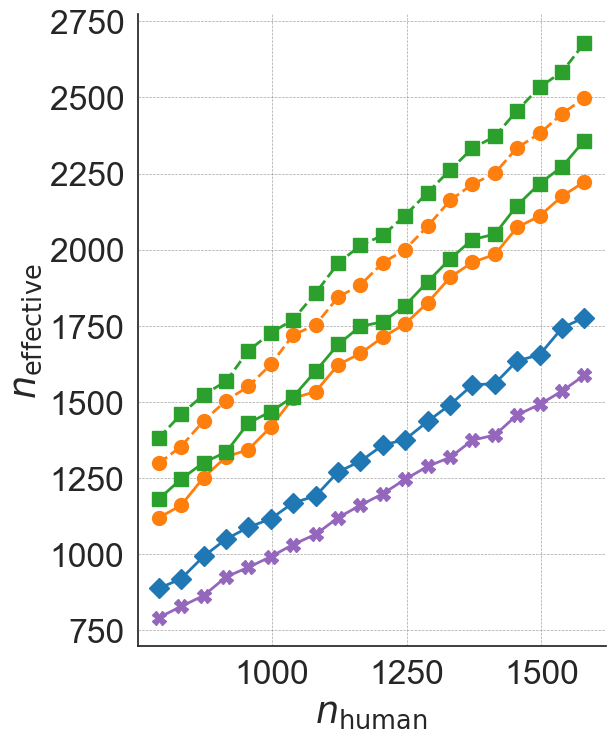

In [22]:
plot_eff_sample_size(df, "plots/CHX_chexmodel_ESS.pdf")

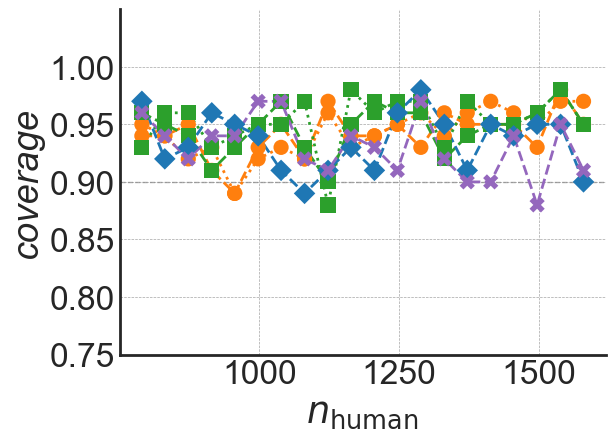

In [23]:
plot_coverage(df, alpha, "plots/CHX_chexmodel_coverage.pdf")

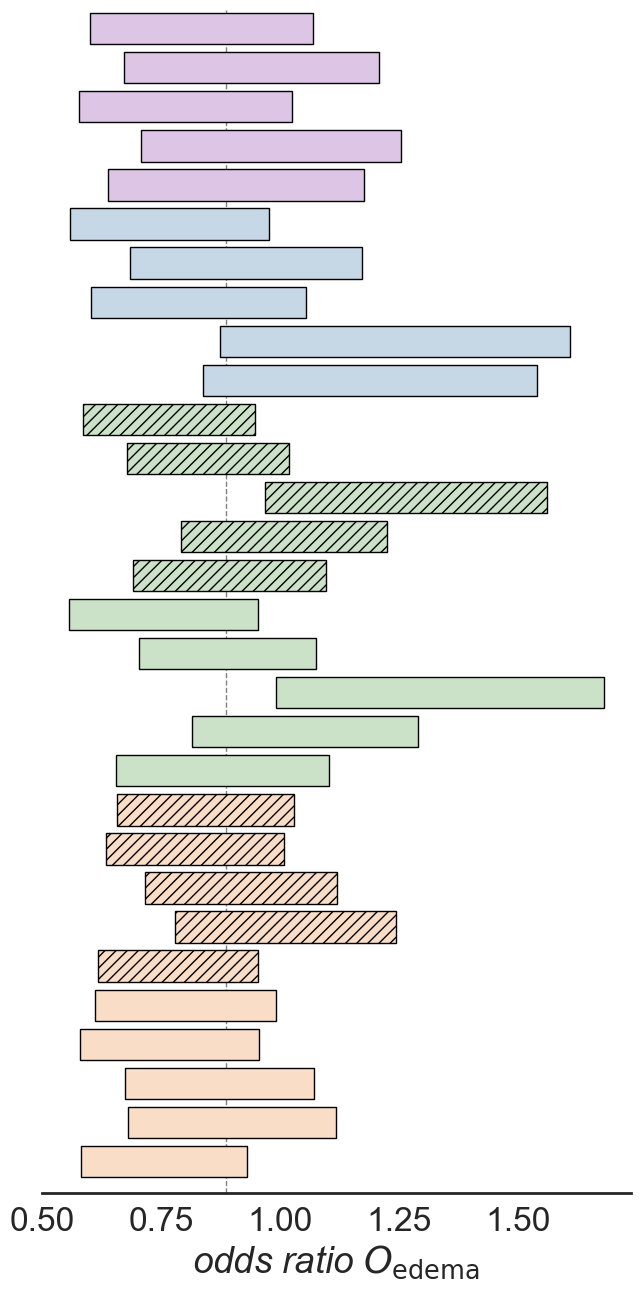

In [24]:
# sample intervals plot
plot_intervals(df, true_odds_ratio, num_trials, "odds ratio $O_{\mathrm{edema}}$", "plots/CHX_chexmodel_intervals.pdf", n_ind=5)